### Import Libraries

In [11]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['ggplot'])
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn import tree

### Read Data

In [12]:
df=pd.read_csv('Telco Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [16]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [17]:
df.isna().sum() # null values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df.shape

(7043, 21)

### Data Wrangling
> Drop kolom CustomerID

In [19]:
df.drop('customerID',axis=1,inplace=True)
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


Insight Demografi & Perilaku Pelanggan
> 1. Status Keluarga: Pelanggan single (tanpa Partner/Dependents) memiliki tingkat churn sangat tinggi. 
   Sebaliknya, pelanggan yang sudah berkeluarga jauh lebih loyal.
> 2. Usia: Pelanggan lansia memiliki rasio churn yang lebih tinggi dibanding non-lansia.
> 3. Kontrak: Sistem bulanan (Month-to-month) adalah pemicu churn terbesar. Kontrak 2 tahun adalah penahan churn terbaik.
> 4. Layanan: Pengguna 'Fiber optic' sangat rentan churn, mengindikasikan kemungkinan masalah kualitas jaringan atau harga layanan.
> 5. Tenure: Semakin singkat masa berlangganan, semakin tinggi risiko pelanggan kabur.


In [20]:
df['TotalCharges'].describe() #menampilkan ringkasan statistik deskriptif khusus untuk kolom TotalCharges

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [21]:
len(df[df['TotalCharges']==" "]) # menghitung jumlah baris yang memiliki nilai kosong (spasi) pada kolom TotalCharges

11

Ubah tipe kolom totalcharges

In [22]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce') # mengubah tipe data kolom TotalCharges menjadi numerik, dengan mengabaikan nilai yang tidak dapat dikonversi (spasi) dan menggantinya dengan NaN
df['TotalCharges'].isna().sum() # menghitung jumlah nilai NaN yang dihasilkan dari konversi sebelumnya, yang menunjukkan jumlah baris yang memiliki nilai kosong pada kolom TotalCharges setelah konversi.

np.int64(11)

In [23]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median()) # mengisi nilai NaN pada kolom TotalCharges dengan nilai median dari kolom tersebut, sehingga tidak ada nilai kosong yang tersisa.
len(df[df['TotalCharges']==" "]) # menghitung kembali jumlah baris yang memiliki nilai kosong (spasi) pada kolom TotalCharges setelah pengisian nilai NaN, yang seharusnya sekarang menjadi 0 karena semua nilai kosong telah diisi dengan median.

0

In [24]:
df['Churn'].value_counts() # menghitung jumlah masing-masing kategori dalam kolom Churn, yang menunjukkan berapa banyak pelanggan yang churn (berhenti menggunakan layanan) dan berapa banyak yang tidak churn.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [25]:
df['Churn']=df['Churn'].apply(lambda x:1 if x=='Yes' else 0) # mengubah nilai dalam kolom Churn menjadi 1 untuk pelanggan yang churn (Yes) dan 0 untuk pelanggan yang tidak churn (No), sehingga kolom Churn sekarang berisi nilai numerik yang dapat digunakan dalam analisis dan pemodelan.
df['Churn'].value_counts() # menghitung kembali jumlah masing-masing kategori dalam kolom Churn setelah konversi, yang seharusnya menunjukkan jumlah pelanggan yang churn (1) dan tidak churn (0) dengan nilai numerik.

Churn
0    5174
1    1869
Name: count, dtype: int64

In [26]:
df['SeniorCitizen']=df['SeniorCitizen'].astype('object') # mengubah tipe data kolom SeniorCitizen menjadi objek (string), karena meskipun awalnya mungkin berupa angka (0 dan 1), kolom ini sebenarnya merepresentasikan kategori (apakah pelanggan adalah senior citizen atau tidak) sehingga lebih tepat untuk diperlakukan sebagai data kategorikal daripada numerik.
df['SeniorCitizen'].value_counts() # menghitung jumlah masing-masing kategori dalam kolom SeniorCitizen setelah konversi, yang menunjukkan berapa banyak pelanggan yang merupakan senior citizen (1) dan berapa banyak yang bukan senior citizen (0) dengan nilai kategorikal.

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [27]:
categorical=list(df.select_dtypes(include=['object']).columns) # membuat daftar nama kolom yang memiliki tipe data objek (string), yang biasanya merupakan kolom kategorikal dalam dataset, sehingga variabel categorical akan berisi nama-nama kolom yang dapat digunakan untuk analisis lebih lanjut atau pemrosesan data kategorikal.
numerical=list(df.select_dtypes(include=['number']).columns)   # membuat daftar nama kolom yang memiliki tipe data numerik, yang biasanya merupakan kolom yang berisi nilai angka dalam dataset, sehingga variabel numerical akan berisi nama-nama kolom yang dapat digunakan untuk analisis lebih lanjut atau pemrosesan data numerik.

In [28]:
categorical 

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [29]:
numerical

['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Removing Churn column from numerical

In [30]:
numerical.remove('Churn')  # menghapus kolom 'Churn' dari daftar numerical karena kolom tersebut sekarang berisi nilai numerik yang merepresentasikan kategori (1 untuk churn dan 0 untuk tidak churn), sehingga lebih tepat untuk diperlakukan sebagai data kategorikal dalam konteks analisis ini.
numerical

['tenure', 'MonthlyCharges', 'TotalCharges']

### Calculating Features Importance


In [31]:
global_mean=df['Churn'].mean() # menghitung rata-rata global dari kolom Churn, yang menunjukkan proporsi pelanggan yang churn dalam dataset secara keseluruhan, sehingga nilai ini dapat digunakan sebagai baseline untuk membandingkan model prediksi churn yang akan dibuat.
round(global_mean,2) # membulatkan nilai rata-rata global dari kolom Churn ke dua desimal, sehingga memberikan representasi yang lebih ringkas dan mudah dibaca dari proporsi pelanggan yang churn dalam dataset.

np.float64(0.27)

Gender

In [32]:
churn_gender=df.groupby('gender').Churn.mean() # menghitung rata-rata churn untuk setiap kategori dalam kolom gender, yang menunjukkan proporsi pelanggan yang churn untuk masing-masing jenis kelamin, sehingga kita dapat melihat apakah ada perbedaan signifikan dalam tingkat churn antara pelanggan laki-laki dan perempuan.
gender_risk= churn_gender/global_mean # menghitung rasio antara rata-rata churn untuk setiap kategori dalam kolom gender dengan rata-rata global churn, yang memberikan gambaran tentang seberapa besar risiko churn untuk setiap jenis kelamin dibandingkan dengan rata-rata keseluruhan, sehingga kita dapat menilai apakah jenis kelamin merupakan faktor yang signifikan dalam prediksi churn.
gender_risk # menampilkan rasio risiko churn untuk setiap kategori dalam

gender
Female    1.014466
Male      0.985807
Name: Churn, dtype: float64

Partner


In [33]:
churn_partner=df.groupby('Partner').Churn.mean()
partner_risk= churn_partner/global_mean
partner_risk
# The differance between rates is small so partner is not important feature

Partner
No     1.241964
Yes    0.741038
Name: Churn, dtype: float64

In [34]:
from sklearn.preprocessing import LabelEncoder # mengimpor kelas LabelEncoder dari modul sklearn.preprocessing, yang digunakan untuk mengubah data kategorikal menjadi format numerik yang dapat digunakan dalam algoritma machine learning.

categorical_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'] # membuat daftar nama kolom yang berisi data kategorikal dalam dataset, yang akan digunakan untuk proses encoding agar data tersebut dapat digunakan dalam model machine learning.

label_encoder = LabelEncoder() # membuat instance dari kelas LabelEncoder, yang akan digunakan untuk melakukan encoding pada kolom-kolom kategorikal dalam dataset, sehingga setiap kategori dalam kolom tersebut akan diubah menjadi nilai numerik yang sesuai.
for col in categorical_columns: # melakukan iterasi melalui setiap nama kolom dalam daftar categorical_columns, dan untuk setiap kolom tersebut, menerapkan metode fit_transform dari label_encoder untuk mengubah nilai kategorikal menjadi nilai numerik yang sesuai, sehingga kolom-kolom kategorikal dalam dataset akan diubah menjadi format yang dapat digunakan dalam model machine learning.
    df[col] = label_encoder.fit_transform(df[col]) # melakukan encoding pada setiap kolom kategorikal dalam dataset menggunakan LabelEncoder, sehingga setiap kategori dalam kolom tersebut diubah menjadi nilai numerik yang sesuai, dan hasilnya disimpan kembali ke dalam kolom yang sama dalam DataFrame df.

In [35]:
df.head(5) # menampilkan 5 baris pertama dari DataFrame df setelah proses encoding, sehingga kita dapat melihat bagaimana data kategorikal telah diubah menjadi format numerik yang sesuai untuk analisis dan pemodelan lebih lanjut.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [36]:
scaler = StandardScaler() # membuat instance dari kelas StandardScaler, yang digunakan untuk melakukan standarisasi pada data numerik dengan mengubahnya menjadi distribusi dengan mean 0 dan standar deviasi 1, sehingga fitur-fitur numerik dalam dataset akan berada pada skala yang sama dan dapat meningkatkan kinerja model machine learning.
df[numerical] = scaler.fit_transform(df[numerical]) # melakukan standarisasi pada kolom-kolom yang terdapat dalam daftar numerical menggunakan StandardScaler, sehingga setiap nilai dalam kolom-kolom tersebut diubah menjadi distribusi dengan mean 0 dan standar deviasi 1, yang dapat membantu meningkatkan kinerja model machine learning dengan memastikan bahwa fitur-fitur numerik berada pada skala yang sama.

df[numerical].head() # menampilkan 5 baris pertama dari kolom-kolom yang terdapat dalam daftar numerical setelah proses standarisasi, sehingga kita dapat melihat bagaimana nilai-nilai dalam kolom-kolom tersebut telah diubah menjadi distribusi dengan mean 0 dan standar deviasi 1.

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.994242
1,0.066327,-0.259629,-0.173244
2,-1.236724,-0.362660,-0.959674
3,0.514251,-0.746535,-0.194766
4,-1.236724,0.197365,-0.940470


### EDA

<Axes: >

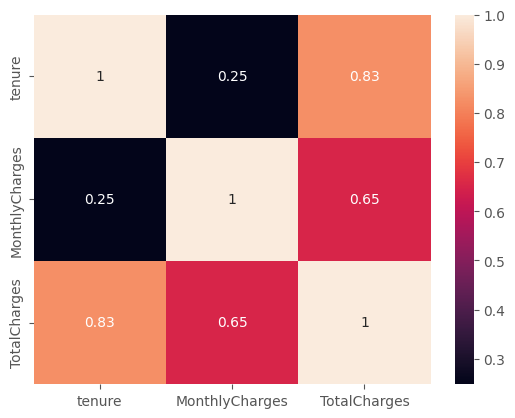

In [37]:
corr_num=df[numerical].corr() # menghitung matriks korelasi untuk kolom-kolom yang terdapat dalam daftar numerical, yang menunjukkan sejauh mana hubungan linear antara setiap pasangan fitur numerik dalam dataset, sehingga kita dapat mengidentifikasi fitur-fitur yang memiliki korelasi tinggi dan mungkin memberikan informasi yang berguna untuk model prediksi churn.
sns.heatmap(corr_num,annot=True) # membuat heatmap menggunakan seaborn untuk memvisualisasikan matriks korelasi yang telah dihitung

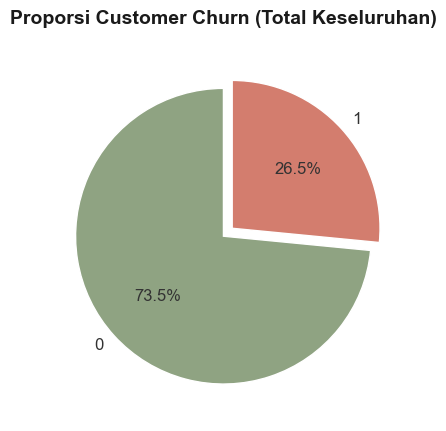

In [49]:
churn_counts = df['Churn'].value_counts()
aesthetic_colors = ['#8FA382', '#D37D6E'] #
plt.pie(churn_counts, 
        labels=churn_counts.index, 
        autopct='%1.1f%%', 
        colors=aesthetic_colors, 
        startangle=90, 
        explode=(0, 0.08), 
        shadow=False, 
        textprops={'fontsize': 12, 'fontweight': '500', 'color': '#333333'})

plt.title('Proporsi Customer Churn (Total Keseluruhan)', 
          fontsize=14, 
          fontweight='bold', 
          color='#1A1A1A', 
          pad=20)

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_29988\2256956976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=corr_data.values, y=corr_data.index, palette='vlag')


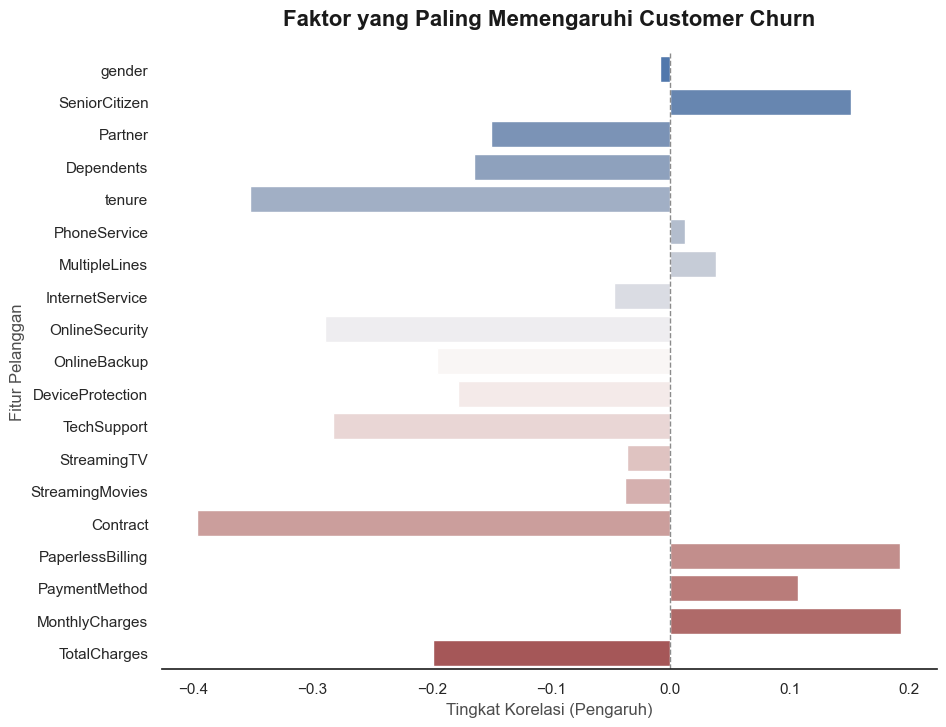

In [39]:
corr_data = df.drop('Churn', axis=1).corrwith(df.Churn)

sns.set_theme(style="white")
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=corr_data.values, y=corr_data.index, palette='vlag')

plt.title('Faktor yang Paling Memengaruhi Customer Churn', 
          fontsize=16, 
          fontweight='bold', 
          color='#1A1A1A', 
          pad=20)
plt.xlabel('Tingkat Korelasi (Pengaruh)', fontsize=12, color='#4D4D4D')
plt.ylabel('Fitur Pelanggan', fontsize=12, color='#4D4D4D')

sns.despine(left=True, bottom=False)
plt.axvline(x=0, color='#8C8C8C', linestyle='--', linewidth=1)

plt.show()

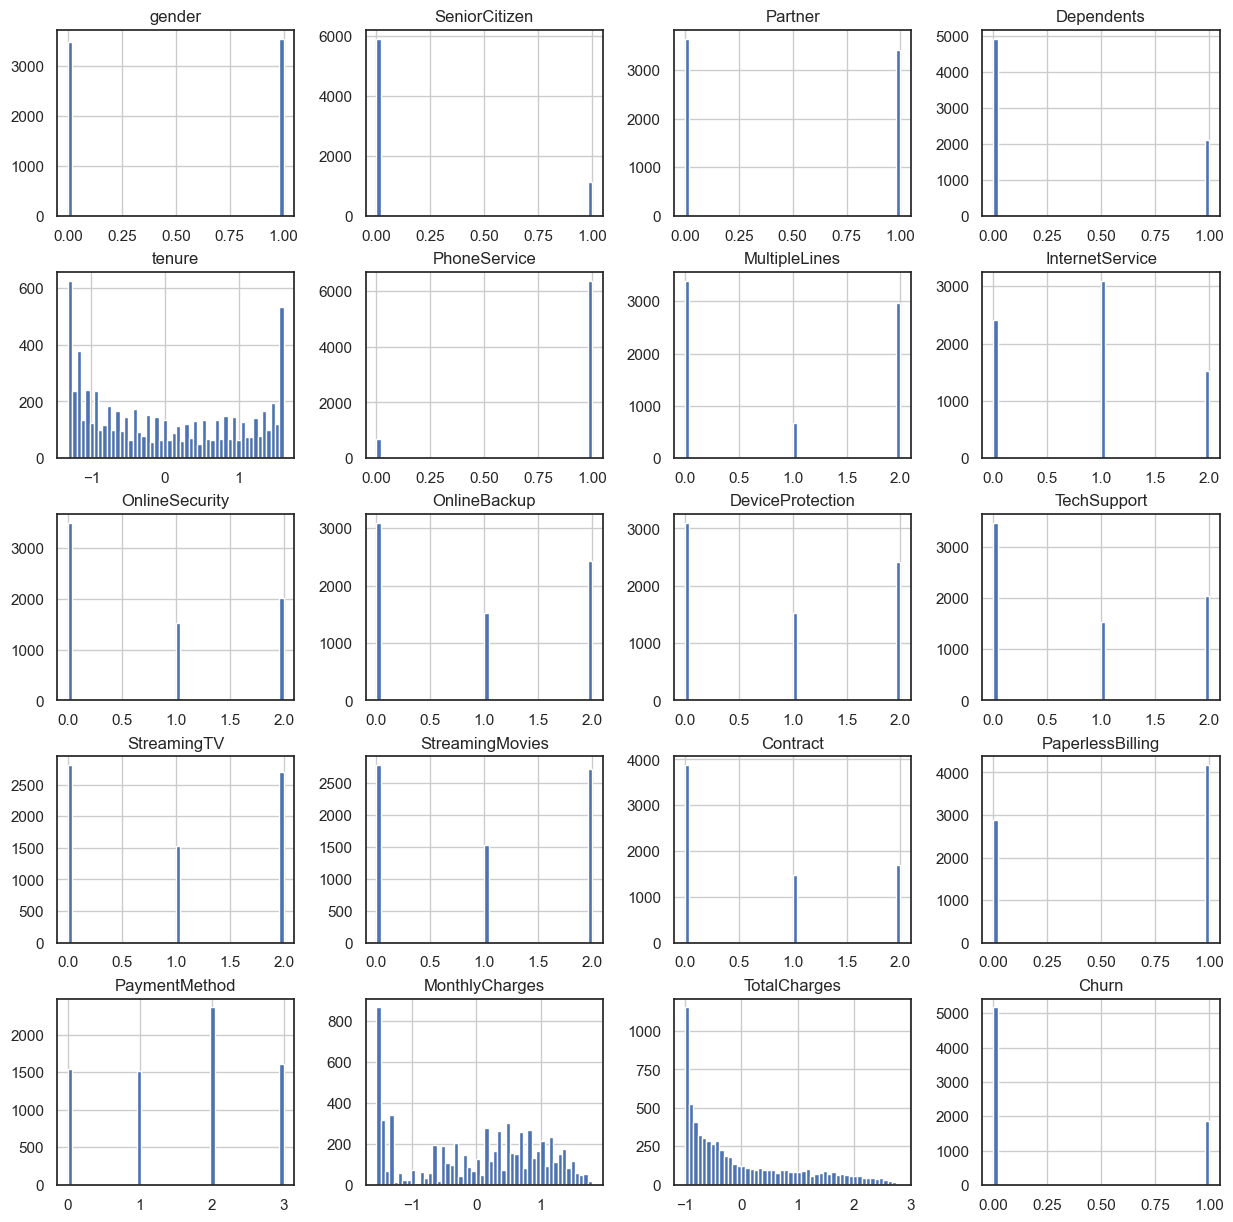

In [40]:
df.hist(bins=50,figsize=(15,15))
plt.show()

### Splitting Dataset

In [41]:
x=df.drop(columns=['Churn'],axis=1) # membuat variabel x yang berisi semua kolom dalam DataFrame df kecuali kolom 'Churn', yang akan digunakan sebagai fitur (variabel independen) dalam model prediksi churn.
y=df['Churn'] # membuat variabel y yang berisi kolom 'Churn' dari DataFrame df, yang akan digunakan sebagai target (variabel dependen) dalam model prediksi churn, sehingga x berisi fitur-fitur yang digunakan untuk memprediksi nilai y (apakah pelanggan churn atau tidak).

In [42]:
y.value_counts() # imbalance

Churn
0    5174
1    1869
Name: count, dtype: int64

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=44) # membagi dataset menjadi data latih (x_train, y_train) dan data uji (x_test, y_test) dengan proporsi 75% untuk data latih dan 25% untuk data uji, serta menggunakan random_state=44 untuk memastikan bahwa pembagian data dapat direproduksi.

print(f"the shape of x_train is : {x_train.shape}") # menampilkan bentuk (jumlah baris dan kolom) dari variabel x_train, yang menunjukkan ukuran data latih yang akan digunakan untuk melatih model prediksi churn, sehingga kita dapat memastikan bahwa data telah dibagi dengan benar sesuai dengan proporsi yang diinginkan.
print(f'the shape of x_test is : {x_test.shape}') # menampilkan bentuk (jumlah baris dan kolom) dari variabel x_test, yang menunjukkan ukuran data uji yang akan digunakan untuk mengevaluasi model prediksi churn, sehingga kita dapat memastikan bahwa data telah dibagi dengan benar sesuai dengan proporsi yang diinginkan.
print(f'the shape of y_tain is : {y_train.shape}') # menampilkan bentuk (jumlah baris) dari variabel y_train, yang menunjukkan ukuran target data latih yang akan digunakan untuk melatih model prediksi churn, sehingga kita dapat memastikan bahwa data telah dibagi dengan benar sesuai dengan proporsi yang diinginkan.
print(f'the shape of y_test is {y_test.shape}') # menampilkan bentuk (jumlah baris) dari variabel y_test, yang menunjukkan ukuran target data uji yang akan digunakan untuk mengevaluasi model prediksi churn, sehingga kita dapat memastikan bahwa data telah dibagi dengan benar sesuai dengan proporsi yang diinginkan.

the shape of x_train is : (5282, 19)
the shape of x_test is : (1761, 19)
the shape of y_tain is : (5282,)
the shape of y_test is (1761,)


### Models

Decision Tree Classifier

In [44]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=4, class_weight='balanced', random_state=44) # membuat instance dari kelas DecisionTreeClassifier dengan menggunakan kriteria "entropy" untuk pemilihan fitur, batas kedalaman maksimum pohon sebesar 4, penanganan ketidakseimbangan kelas dengan class_weight='balanced', dan random_state=44 untuk memastikan bahwa hasil yang diperoleh dapat direproduksi.
model_dt = dt.fit(x_train, y_train) # melatih model Decision Tree menggunakan data latih (x_train dan y_train), sehingga model akan belajar pola-pola dalam data untuk dapat memprediksi apakah pelanggan akan churn atau tidak berdasarkan fitur-fitur yang ada.
y_pred_dt = model_dt.predict(x_test) # menggunakan model Decision Tree yang telah dilatih untuk memprediksi nilai target (churn atau tidak churn) pada data uji (x_test), sehingga kita dapat mengevaluasi kinerja model dengan membandingkan prediksi (y_pred_dt) dengan nilai aktual (y_test).
print(classification_report(y_test, y_pred_dt)) # menampilkan laporan klasifikasi yang mencakup metrik seperti precision, recall, f1-score, dan support untuk setiap kelas dalam target (churn atau tidak churn), sehingga kita dapat mengevaluasi kinerja model Decision Tree dalam memprediksi churn pelanggan.

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1298
           1       0.55      0.71      0.62       463

    accuracy                           0.77      1761
   macro avg       0.72      0.75      0.73      1761
weighted avg       0.80      0.77      0.78      1761



Logistic Regression

In [46]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=44) # membuat instance dari kelas LogisticRegression dengan penanganan ketidakseimbangan kelas menggunakan class_weight='balanced', batas iterasi maksimum sebesar 1000 untuk memastikan konvergensi, dan random_state=44 untuk memastikan bahwa hasil yang diperoleh dapat direproduksi.
model_lr = lr.fit(x_train, y_train) # melatih model Logistic Regression menggunakan data latih (x_train dan y_train), sehingga model akan belajar pola-pola dalam data untuk dapat memprediksi apakah pelanggan akan churn atau tidak berdasarkan fitur-fitur yang ada.
y_pred_lr = model_lr.predict(x_test) # menggunakan model Logistic Regression yang telah dilatih untuk memprediksi nilai target (churn atau tidak churn) pada data uji (x_test), sehingga kita dapat mengevaluasi kinerja model dengan membandingkan prediksi (y_pred_lr) dengan nilai aktual (y_test).
print(classification_report(y_test, y_pred_lr)) # menampilkan laporan klasifikasi yang mencakup metrik seperti precision, recall, f1-score, dan support untuk setiap kelas dalam target (churn atau tidak churn), sehingga kita dapat mengevaluasi kinerja model Logistic Regression dalam memprediksi churn pelanggan.

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1298
           1       0.51      0.81      0.63       463

    accuracy                           0.74      1761
   macro avg       0.71      0.77      0.72      1761
weighted avg       0.81      0.74      0.76      1761



Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=44) # membuat instance dari kelas RandomForestClassifier dengan menggunakan 100 pohon keputusan (n_estimators=100), batas kedalaman maksimum pohon sebesar 6 (max_depth=6), penanganan ketidakseimbangan kelas dengan class_weight='balanced', dan random_state=44 untuk memastikan bahwa hasil yang diperoleh dapat direproduksi.
model_rf = rf.fit(x_train, y_train) # melatih model Random Forest menggunakan data latih (x_train dan y_train), sehingga model akan belajar pola-pola dalam data untuk dapat memprediksi apakah pelanggan akan churn atau tidak berdasarkan fitur-fitur yang ada, dengan menggunakan ensemble dari beberapa pohon keputusan untuk meningkatkan akurasi dan mengurangi overfitting.
y_pred_rf = model_rf.predict(x_test) # menggunakan model Random Forest yang telah dilatih untuk memprediksi nilai target (churn atau tidak churn) pada data uji (x_test), sehingga kita dapat mengevaluasi kinerja model dengan membandingkan prediksi (y_pred_rf) dengan nilai aktual (y_test).
print(classification_report(y_test, y_pred_rf)) # menampilkan laporan klasifikasi yang mencakup metrik seperti precision, recall, f1-score, dan support untuk setiap kelas dalam target (churn atau tidak churn), sehingga kita dapat mengevaluasi kinerja model Random Forest dalam memprediksi churn pelanggan.

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1298
           1       0.52      0.79      0.63       463

    accuracy                           0.75      1761
   macro avg       0.71      0.77      0.72      1761
weighted avg       0.81      0.75      0.77      1761

